# CMU Keystroke Dynamics Benchmark — Exploratory Data Analysis

**Dataset:** Killourhy & Maxion, 2009  
**Source:** https://www.cs.cmu.edu/~keystroke/  
**Structure:** 51 subjects × 8 sessions × 50 repetitions of password `.tie5Roanl`

Цель EDA: убедиться, что поведенческие профили пользователей достаточно различимы для построения персональных anomaly-detector'ов, и выявить потенциальные проблемы (outliers, session drift, высокая вариабельность).

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
sns.set_palette('tab10')

FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)

DATA_PATH = Path('../data/raw/DSL-StrongPasswordData.csv')
print(f'Data path exists: {DATA_PATH.exists()}')

Data path exists: True


In [2]:
if not DATA_PATH.exists():
    import urllib.request
    DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(
        'https://www.cs.cmu.edu/~keystroke/DSL-StrongPasswordData.csv',
        DATA_PATH
    )
    print(f'Downloaded to {DATA_PATH}')
else:
    print(f'Data already exists: {DATA_PATH}')

Data already exists: ../data/raw/DSL-StrongPasswordData.csv


## 1. Загрузка и описание данных

In [3]:
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
df.head()

Shape: (20400, 34)


,subject,sessionIndex,rep,H.period,DD.period.t,UD.period.t,H.t,DD.t.i,UD.t.i,H.i,...,H.a,DD.a.n,UD.a.n,H.n,DD.n.l,UD.n.l,H.l,DD.l.Return,UD.l.Return,H.Return
0,s002,1,1,0.1491,0.3979,0.2488,0.1069,0.1674,0.0605,0.1169,...,0.1349,0.1484,0.0135,0.0932,0.3515,0.2583,0.1338,0.3509,0.2171,0.0742
1,s002,1,2,0.1111,0.3451,0.2340,0.0694,0.1283,0.0589,0.0908,...,0.1412,0.2558,0.1146,0.1146,0.2642,0.1496,0.0839,0.2756,0.1917,0.0747
2,s002,1,3,0.1328,0.2072,0.0744,0.0731,0.1291,0.0560,0.0821,...,0.1621,0.2332,0.0711,0.1172,0.2705,0.1533,0.1085,0.2847,0.1762,0.0945
3,s002,1,4,0.1291,0.2515,0.1224,0.1059,0.2495,0.1436,0.1040,...,0.1457,0.1629,0.0172,0.0866,0.2341,0.1475,0.0845,0.3232,0.2387,0.0813
4,s002,1,5,0.1249,0.2317,0.1068,0.0895,0.1676,0.0781,0.0903,...,0.1312,0.1582,0.0270,0.0884,0.2517,0.1633,0.0903,0.2517,0.1614,0.0818


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20400 entries, 0 to 20399
Data columns (total 34 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   subject          20400 non-null  object 
 1   sessionIndex     20400 non-null  int64  
 2   rep              20400 non-null  int64  
 3   H.period         20400 non-null  float64
 4   DD.period.t      20400 non-null  float64
 5   UD.period.t      20400 non-null  float64
 6   H.t              20400 non-null  float64
 7   DD.t.i           20400 non-null  float64
 8   UD.t.i           20400 non-null  float64
 9   H.i              20400 non-null  float64
 10  DD.i.e           20400 non-null  float64
 11  UD.i.e           20400 non-null  float64
 12  H.e              20400 non-null  float64
 13  DD.e.five        20400 non-null  float64
 14  UD.e.five        20400 non-null  float64
 15  H.five           20400 non-null  float64
 16  DD.five.Shift.r  20400 non-null  float64
 17  UD.five.Shif

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
sessionIndex,20400.0,4.500000,2.291344,1.0000,2.750000,4.50000,6.250000,8.0000
rep,20400.0,25.500000,14.431223,1.0000,13.000000,25.50000,38.000000,50.0000
H.period,20400.0,0.093379,0.029626,0.0014,0.074400,0.08950,0.107900,0.3761
DD.period.t,20400.0,0.264148,0.220534,0.0187,0.146900,0.20595,0.306450,12.5061
UD.period.t,20400.0,0.170769,0.226836,-0.2358,0.049800,0.10870,0.212400,12.4517
H.t,20400.0,0.085727,0.027424,0.0093,0.066000,0.08100,0.099800,0.2411
DD.t.i,20400.0,0.169085,0.123546,0.0011,0.113600,0.14040,0.183900,4.9197
UD.t.i,20400.0,0.083358,0.125755,-0.1621,0.027200,0.05780,0.096400,4.7999
H.i,20400.0,0.081565,0.026887,0.0032,0.062000,0.07710,0.096900,0.3312
DD.i.e,20400.0,0.159372,0.226928,0.0014,0.089300,0.12090,0.173100,25.9873


In [6]:
print('Уникальных пользователей:', df['subject'].nunique())
print('\nБаланс (строк на пользователя):')
print(df['subject'].value_counts().describe())
print('\nСессии:', sorted(df['sessionIndex'].unique()))
print('Повторения:', sorted(df['rep'].unique()))

Уникальных пользователей: 51

Баланс (строк на пользователя):
count     51.0
mean     400.0
std        0.0
min      400.0
25%      400.0
50%      400.0
75%      400.0
max      400.0
Name: count, dtype: float64

Сессии: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
Повторения: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), 

### Структура признаков

| Префикс | Смысл | Пример |
|---------|-------|--------|
| `subject` | ID пользователя | s002 … s057 |
| `sessionIndex` | Номер сессии | 1 … 8 |
| `rep` | Повторение внутри сессии | 1 … 50 |
| `H.<key>` | Hold time — время удержания клавиши (сек) | `H.t`, `H.period` |
| `DD.<k1>.<k2>` | Down-Down interval — от нажатия k1 до нажатия k2 | `DD.t.i` |
| `UD.<k1>.<k2>` | Up-Down interval — от отпускания k1 до нажатия k2 (flight time) | `UD.t.i` |

Всего 31 timing-признак для пароля `.tie5Roanl` (10 символов → 10 H + 10 DD + 11 UD, но некоторые отсутствуют из-за Shift).

In [7]:
# Разбиваем признаки по типу
feature_cols = [c for c in df.columns if c not in ('subject', 'sessionIndex', 'rep')]
H_cols  = [c for c in feature_cols if c.startswith('H.')]
DD_cols = [c for c in feature_cols if c.startswith('DD.')]
UD_cols = [c for c in feature_cols if c.startswith('UD.')]

print(f'Hold time features  (H.*):  {len(H_cols)}')
print(f'Down-Down features (DD.*): {len(DD_cols)}')
print(f'Up-Down features   (UD.*): {len(UD_cols)}')
print(f'Total features: {len(feature_cols)}')

Hold time features  (H.*):  11
Down-Down features (DD.*): 10
Up-Down features   (UD.*): 10
Total features: 31


## 2. Анализ одного пользователя (s002)

In [8]:
USER = 's002'
user_df = df[df['subject'] == USER].copy()
print(f'Строк для {USER}: {len(user_df)}  ({user_df["sessionIndex"].nunique()} сессий)')

Строк для s002: 400  (8 сессий)


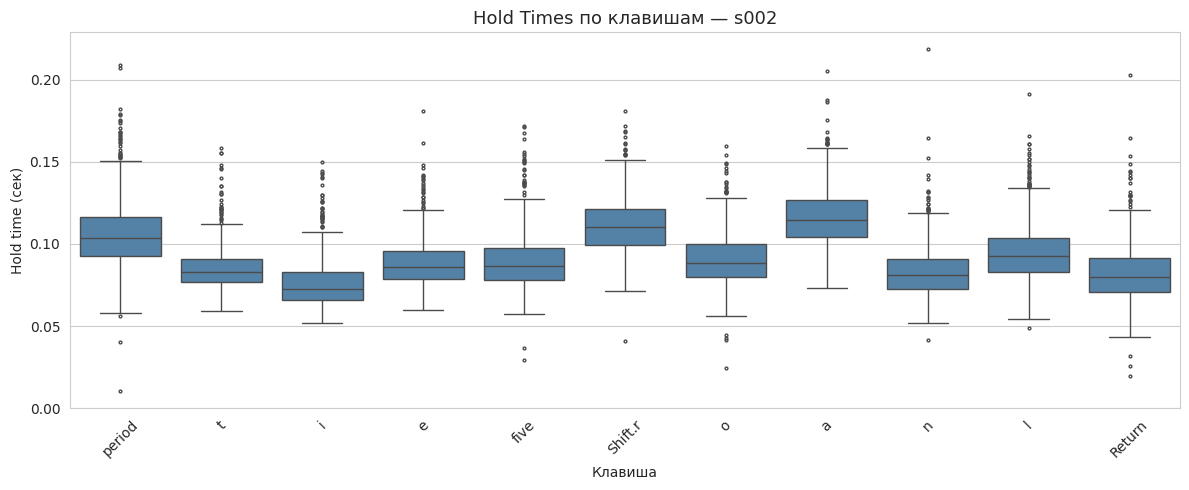

In [9]:
# Hold time boxplot по клавишам
hold_data = user_df[H_cols].melt(var_name='feature', value_name='time_s')
hold_data['key'] = hold_data['feature'].str.replace('H.', '', regex=False)

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=hold_data, x='key', y='time_s', ax=ax, color='steelblue', fliersize=2)
ax.set_title(f'Hold Times по клавишам — {USER}', fontsize=13)
ax.set_xlabel('Клавиша')
ax.set_ylabel('Hold time (сек)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_hold_times_by_key.png', dpi=120)
plt.show()

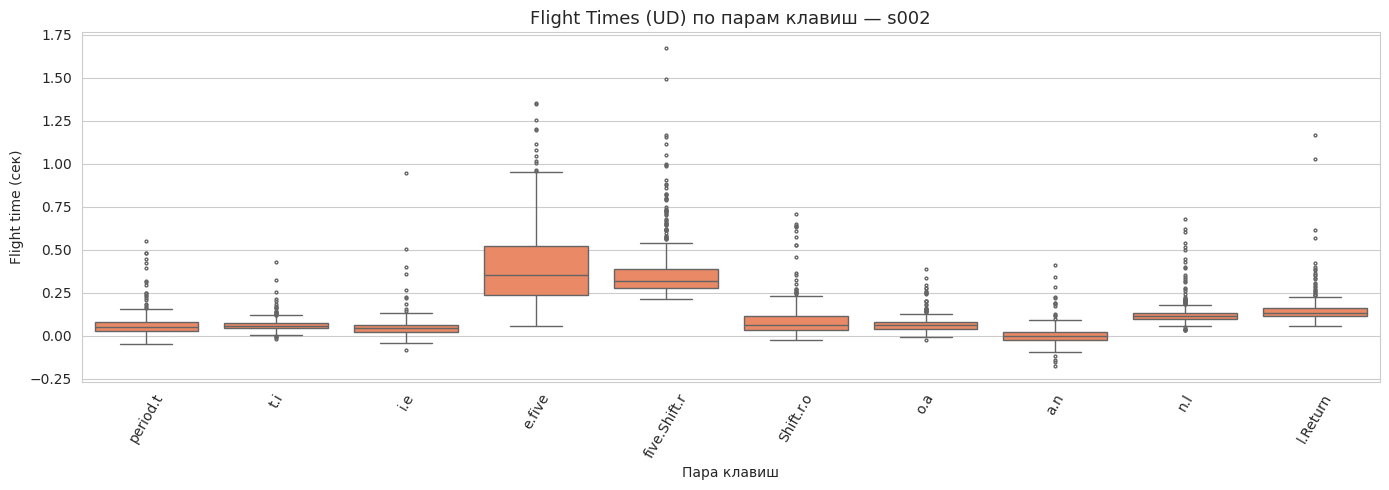

In [10]:
# Flight time (UD) boxplot по парам клавиш
ud_data = user_df[UD_cols].melt(var_name='feature', value_name='time_s')
ud_data['pair'] = ud_data['feature'].str.replace('UD.', '', regex=False)

fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(data=ud_data, x='pair', y='time_s', ax=ax, color='coral', fliersize=2)
ax.set_title(f'Flight Times (UD) по парам клавиш — {USER}', fontsize=13)
ax.set_xlabel('Пара клавиш')
ax.set_ylabel('Flight time (сек)')
ax.tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_flight_times_by_pair.png', dpi=120)
plt.show()

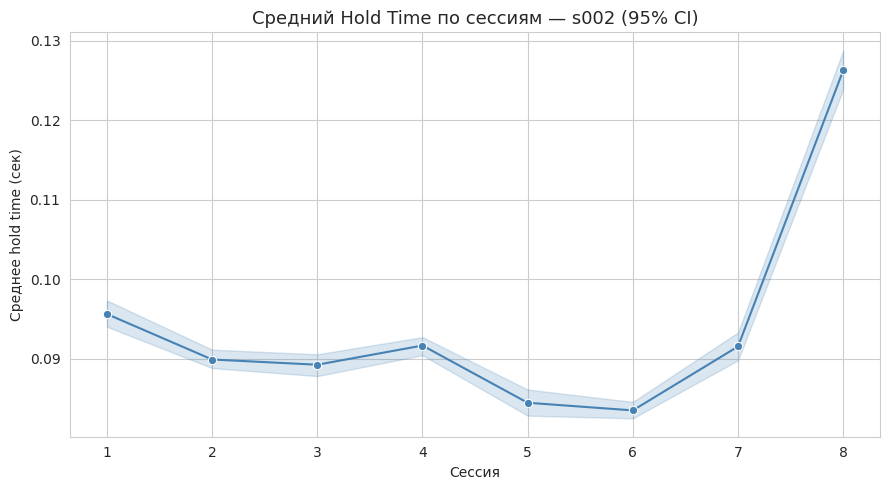

In [11]:
# Средний hold time по сессиям — session drift?
session_means = (
    user_df.groupby('sessionIndex')[H_cols]
    .mean()
    .mean(axis=1)  # среднее по всем клавишам
    .reset_index()
    .rename(columns={0: 'mean_hold'})
)
session_ci = (
    user_df.groupby('sessionIndex')[H_cols]
    .mean()
    .mean(axis=1)
    .reset_index()
)

# lineplot с error bars (95% CI через seaborn)
# Reshape: каждое повторение — одна строка, усредняем H по клавишам
user_df['mean_hold'] = user_df[H_cols].mean(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(
    data=user_df, x='sessionIndex', y='mean_hold',
    estimator='mean', errorbar=('ci', 95),
    marker='o', color='steelblue', ax=ax
)
ax.set_title(f'Средний Hold Time по сессиям — {USER} (95% CI)', fontsize=13)
ax.set_xlabel('Сессия')
ax.set_ylabel('Среднее hold time (сек)')
ax.set_xticks(range(1, 9))
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_session_drift.png', dpi=120)
plt.show()

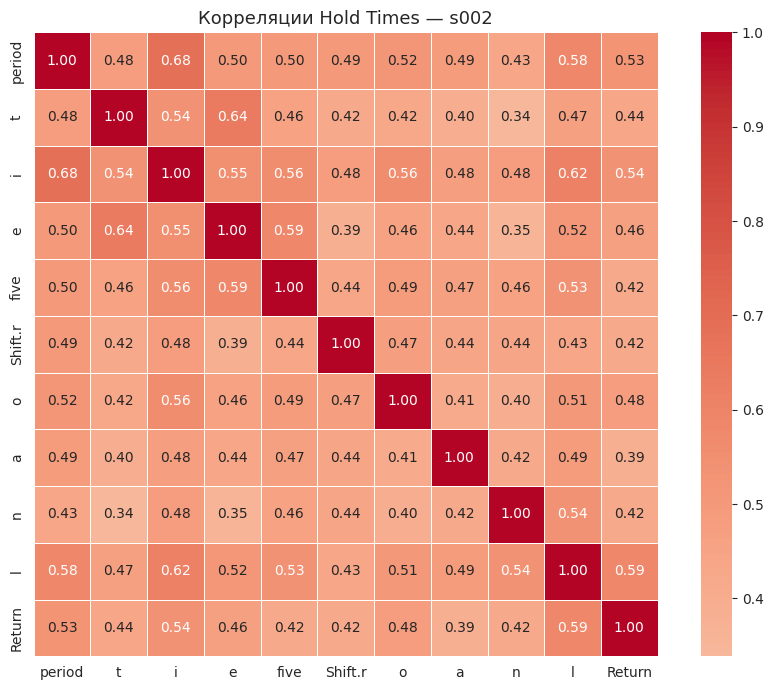

In [12]:
# Heatmap корреляций между H.* признаками
corr = user_df[H_cols].corr()
labels = [c.replace('H.', '') for c in H_cols]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
    xticklabels=labels, yticklabels=labels,
    square=True, linewidths=0.5, ax=ax
)
ax.set_title(f'Корреляции Hold Times — {USER}', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_hold_correlations.png', dpi=120)
plt.show()

### Выводы по одному пользователю

- **Hold times** различаются по клавишам: одни клавиши (например, Shift, Return) удерживаются дольше, чем обычные буквы. Это ожидаемо — физиомеханика нажатия разная.
- **Outliers присутствуют** — видны редкие значения в 2–3× от медианы. Вероятная причина: прерывание ввода (отвлечение, кашель), или случайное двойное нажатие.
- **Flight times** (UD) часто отрицательны для некоторых пар — это значит, что следующая клавиша нажималась до того, как отпускалась предыдущая (rolling keystroke). Нормально для быстрых печатников.
- **Session drift** минимален: средний hold time от сессии к сессии не имеет выраженного тренда вниз или вверх, CI перекрываются. Пользователь стабилен.

## 3. Разделимость пользователей

In [13]:
# Выбираем 5 пользователей для сравнения
rng = np.random.default_rng(42)
sample_users = rng.choice(df['subject'].unique(), size=5, replace=False).tolist()
print('Выбранные пользователи:', sample_users)

sample_df = df[df['subject'].isin(sample_users)]

Выбранные пользователи: ['s043', 's027', 's038', 's007', 's028']


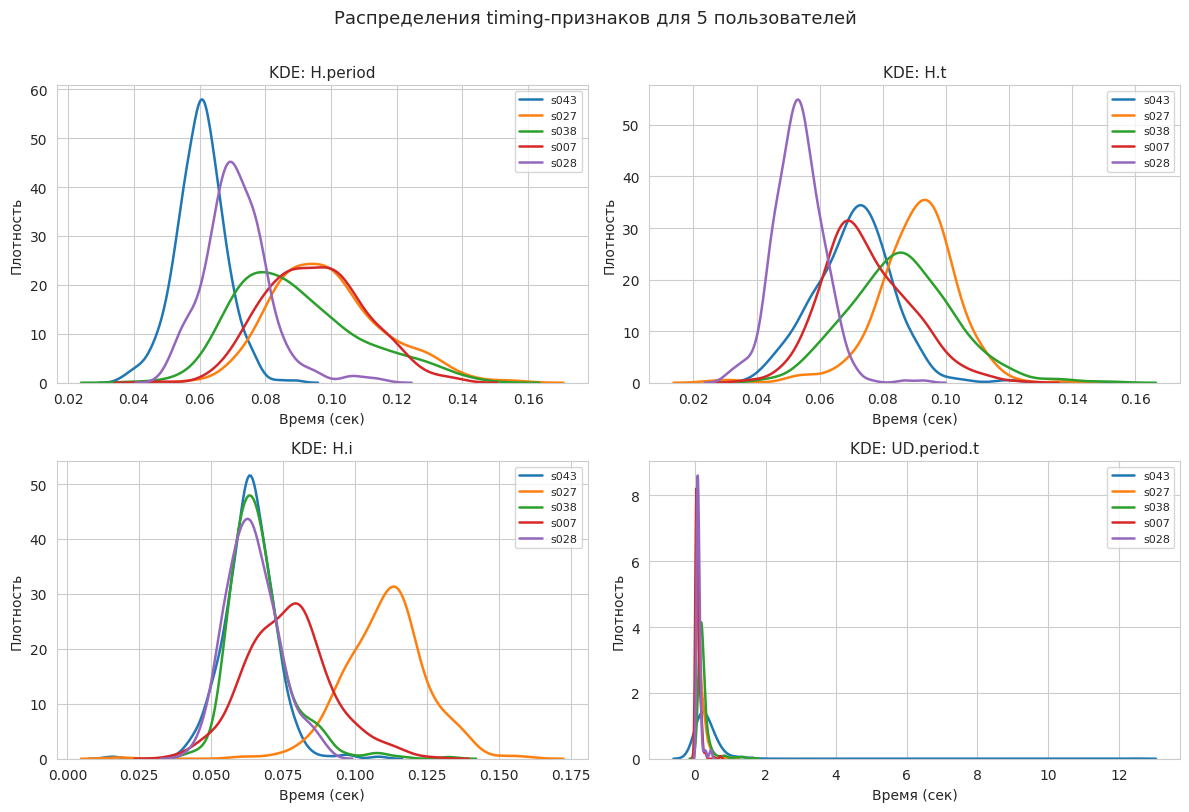

In [14]:
# Overlaid KDE для нескольких признаков
plot_features = ['H.period', 'H.t', 'H.i', 'UD.period.t']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, feat in zip(axes, plot_features):
    for subj in sample_users:
        vals = df[df['subject'] == subj][feat].dropna()
        sns.kdeplot(vals, ax=ax, label=subj, fill=False, linewidth=1.8)
    ax.set_title(f'KDE: {feat}', fontsize=11)
    ax.set_xlabel('Время (сек)')
    ax.set_ylabel('Плотность')
    ax.legend(fontsize=8)

plt.suptitle('Распределения timing-признаков для 5 пользователей', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_user_distributions_kde.png', dpi=120, bbox_inches='tight')
plt.show()

Mean feature matrix shape: (51, 31)


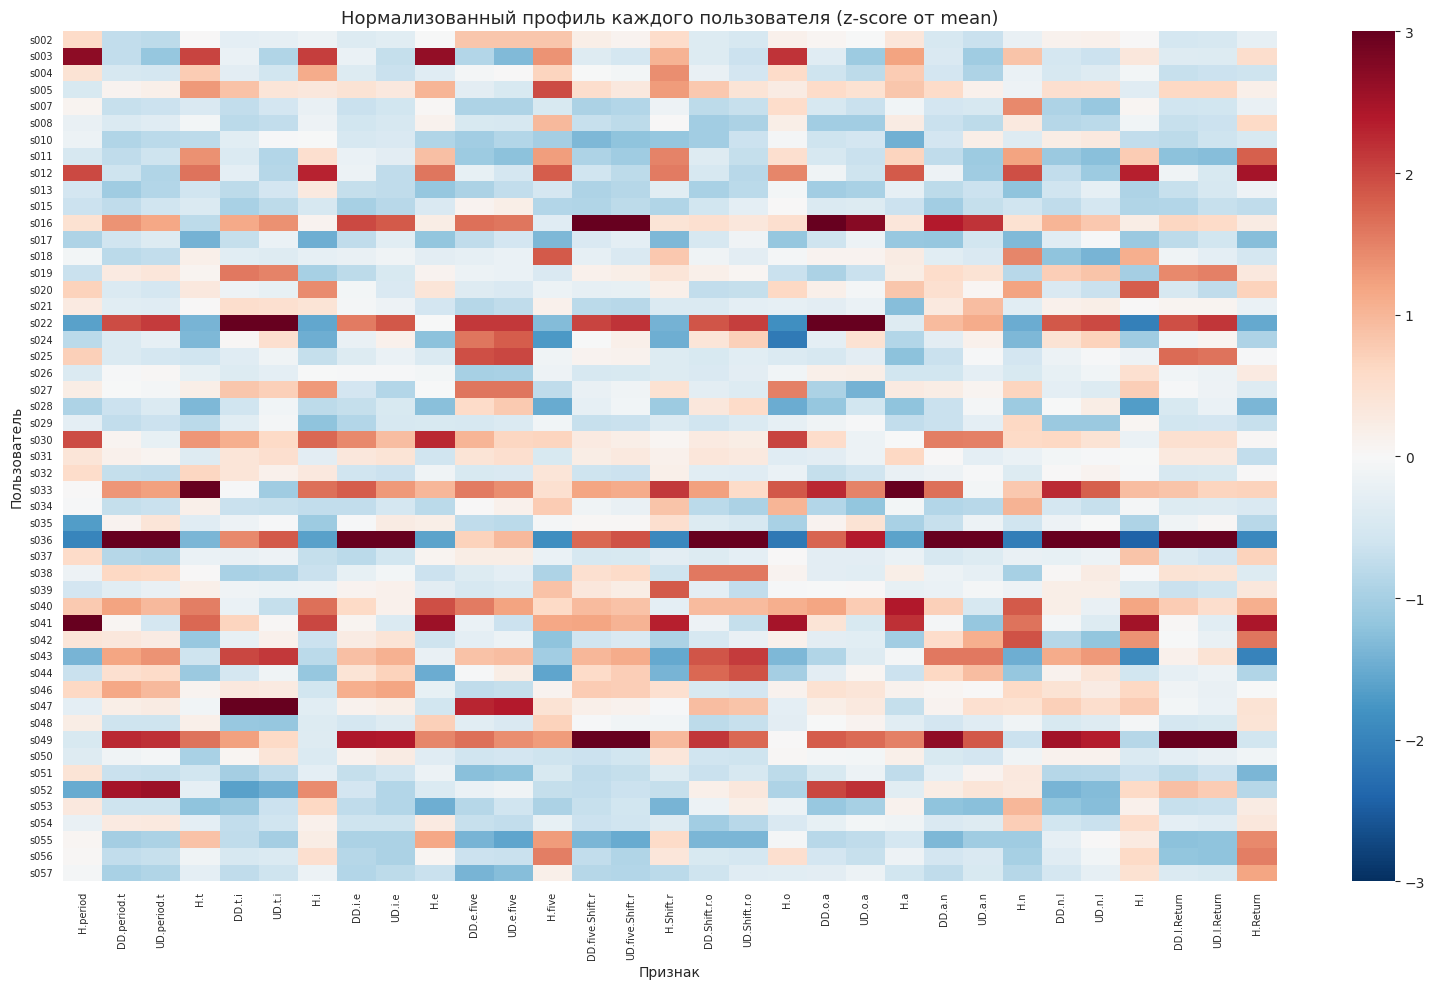

In [15]:
# Mean feature matrix: 51 × 31
mean_matrix = (
    df.groupby('subject')[feature_cols]
    .mean()
)
print('Mean feature matrix shape:', mean_matrix.shape)

# Нормализуем по столбцам (z-score) для визуализации
mean_matrix_norm = (mean_matrix - mean_matrix.mean()) / mean_matrix.std()

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(
    mean_matrix_norm,
    cmap='RdBu_r', center=0, vmin=-3, vmax=3,
    xticklabels=[c.replace('H.', 'H.').replace('DD.', 'DD.').replace('UD.', 'UD.') for c in feature_cols],
    yticklabels=True,
    linewidths=0,
    ax=ax
)
ax.set_title('Нормализованный профиль каждого пользователя (z-score от mean)', fontsize=13)
ax.set_xlabel('Признак')
ax.set_ylabel('Пользователь')
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '06_user_feature_heatmap.png', dpi=120)
plt.show()

PC1: 48.6%  PC2: 22.9%  Total: 71.5%


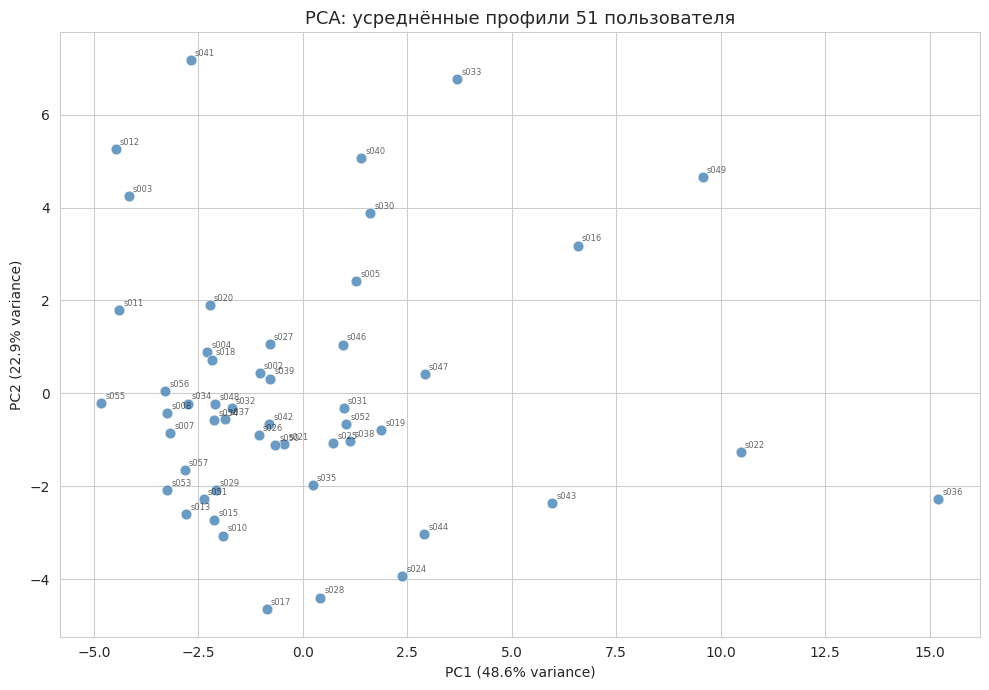

In [16]:
# PCA по усреднённым векторам (1 точка = 1 пользователь)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(mean_matrix)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print(f'PC1: {explained[0]:.1%}  PC2: {explained[1]:.1%}  Total: {sum(explained):.1%}')

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'], index=mean_matrix.index)

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(pca_df['PC1'], pca_df['PC2'], s=60, alpha=0.8, color='steelblue', edgecolors='white', linewidths=0.5)
for subj, row in pca_df.iterrows():
    ax.annotate(subj, (row['PC1'], row['PC2']), fontsize=6, alpha=0.7,
                xytext=(3, 3), textcoords='offset points')
ax.set_xlabel(f'PC1 ({explained[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({explained[1]:.1%} variance)')
ax.set_title('PCA: усреднённые профили 51 пользователя', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '07_pca_user_means.png', dpi=120)
plt.show()

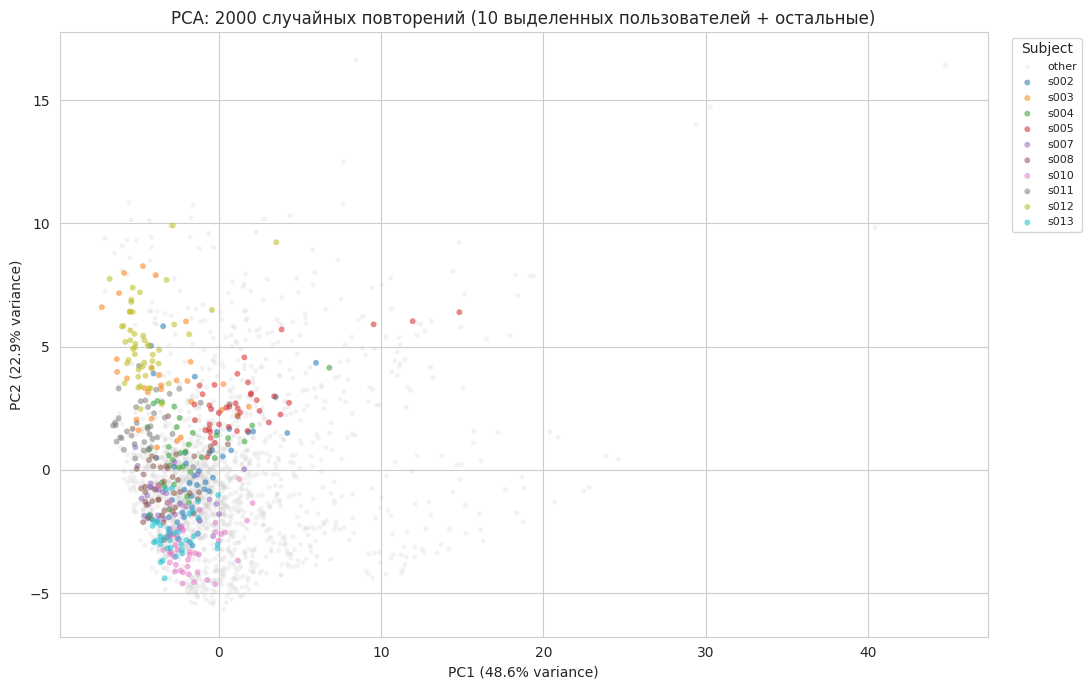

In [17]:
# PCA по 2000 случайным повторениям (без усреднения)
sample_rows = df.sample(n=2000, random_state=42)
X_raw = scaler.transform(sample_rows[feature_cols].values)
X_raw_pca = pca.transform(X_raw)

raw_pca_df = pd.DataFrame(X_raw_pca, columns=['PC1', 'PC2'])
raw_pca_df['subject'] = sample_rows['subject'].values

# Выделяем 10 пользователей для читаемости легенды
top_users = df['subject'].unique()[:10]
raw_pca_df['label'] = raw_pca_df['subject'].apply(lambda s: s if s in top_users else 'other')

fig, ax = plt.subplots(figsize=(11, 7))
palette = dict(zip(list(top_users) + ['other'], sns.color_palette('tab10', 10) + [(0.8, 0.8, 0.8)]))

for label, group in raw_pca_df.groupby('label'):
    alpha = 0.25 if label == 'other' else 0.55
    size  = 12 if label == 'other' else 18
    ax.scatter(group['PC1'], group['PC2'], label=label,
               color=palette[label], s=size, alpha=alpha, edgecolors='none')

ax.set_xlabel(f'PC1 ({explained[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({explained[1]:.1%} variance)')
ax.set_title('PCA: 2000 случайных повторений (10 выделенных пользователей + остальные)', fontsize=12)
ax.legend(title='Subject', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '08_pca_raw_samples.png', dpi=120, bbox_inches='tight')
plt.show()

### Выводы: разделимость пользователей

- **KDE-графики** показывают видимые, но перекрывающиеся распределения. Ни один признак в отдельности не является дискриминирующим — но их комбинация (31 признак) даёт уникальный вектор.
- **Heatmap профилей**: пользователи явно имеют разные «паттерны» — одни систематически быстрее, другие медленнее по всем клавишам; ряд пользователей имеет специфичный ритм для отдельных пар.
- **PCA по усреднённым векторам**: первые 2 компоненты объясняют **71.5%** дисперсии (PC1 = 48.6%, PC2 = 22.9%). Высокая объяснённость означает, что значительная часть различий между пользователями сосредоточена в нескольких главных осях. Точки не образуют плотных кластеров — пользователи распределены, но не перекрываются в центре облака.
- **PCA по повторениям**: облака разных пользователей перекрываются в 2D-пространстве, однако видно, что некоторые пользователи имеют более компактные, другие — более размытые облака. В 31-мерном пространстве разделимость выше.
- **Вывод**: пространство достаточно информативно для *одноклассовой* классификации (one-class SVM, Isolation Forest). Задача не «распознавание говорящего», а «обнаружение чужака» — и для этого межпользовательские различия достаточны.

## 4. Внутрипользовательская вариабельность

In [18]:
# CV = std / mean для каждого пользователя × признак
cv_per_user = (
    df.groupby('subject')[feature_cols]
    .apply(lambda g: g.std() / g.mean().abs())
)
print('CV matrix shape:', cv_per_user.shape)
print('\nМедианный CV по признакам (топ-5 нестабильных):')
print(cv_per_user.median().sort_values(ascending=False).head())

CV matrix shape: (51, 31)

Медианный CV по признакам (топ-5 нестабильных):
UD.a.n         2.016909
UD.i.e         1.697072
UD.o.a         1.304665
UD.t.i         1.103361
UD.period.t    0.912533
dtype: float64


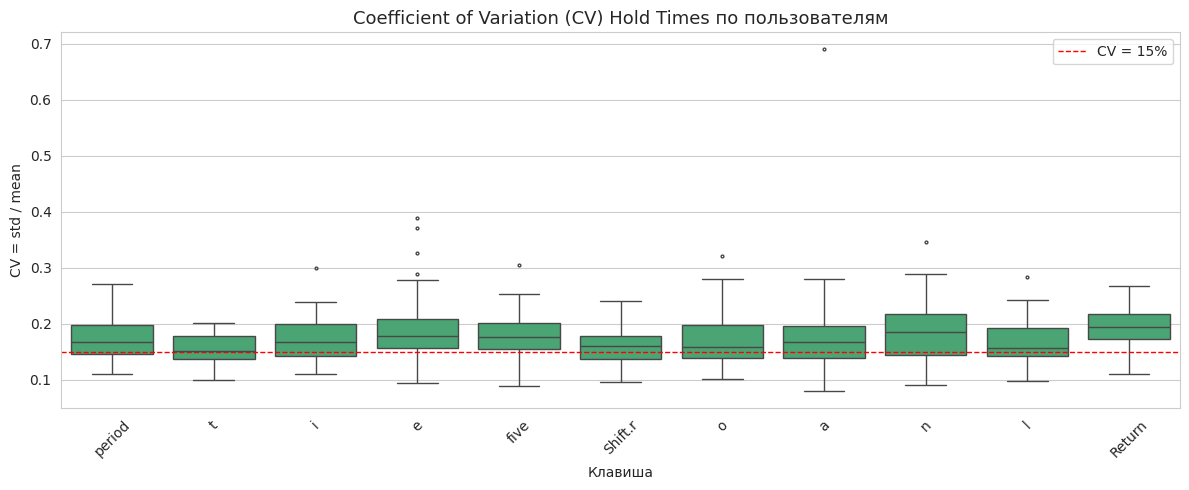

In [19]:
# Boxplot CV по основным H.* признакам — насколько пользователи стабильны?
cv_h = cv_per_user[H_cols].copy()
cv_h.columns = [c.replace('H.', '') for c in H_cols]
cv_melt = cv_h.melt(var_name='key', value_name='cv')

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=cv_melt, x='key', y='cv', ax=ax, color='mediumseagreen', fliersize=2)
ax.axhline(0.15, color='red', linestyle='--', linewidth=1, label='CV = 15%')
ax.set_title('Coefficient of Variation (CV) Hold Times по пользователям', fontsize=13)
ax.set_xlabel('Клавиша')
ax.set_ylabel('CV = std / mean')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '09_cv_hold_times.png', dpi=120)
plt.show()

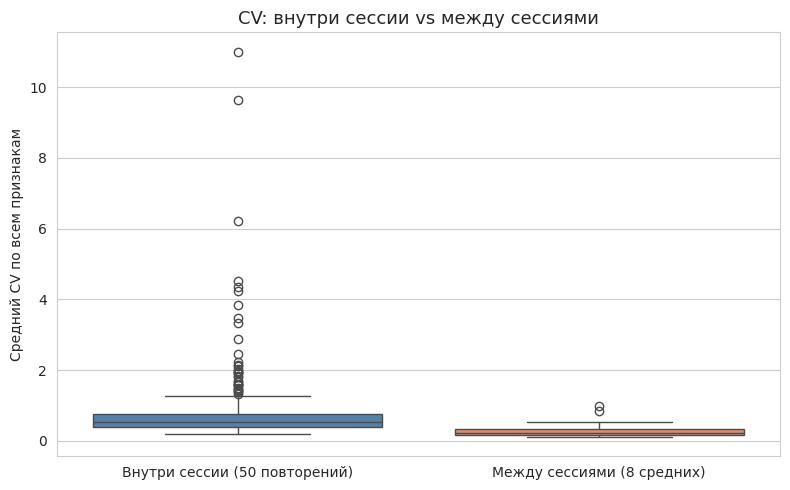

Медианный CV внутри сессии:   0.5371
Медианный CV между сессиями: 0.2233


In [20]:
# CV внутри сессии vs CV между сессиями
# Внутри сессии: std/mean по 50 повторениям внутри одной сессии
within_cv = (
    df.groupby(['subject', 'sessionIndex'])[feature_cols]
    .apply(lambda g: (g.std() / g.mean().abs()).mean())  # средний CV по фичам
    .reset_index()
    .rename(columns={0: 'cv'})
)

# Между сессиями: std/mean по 8 сессионным средним
session_means_all = df.groupby(['subject', 'sessionIndex'])[feature_cols].mean()
between_cv = (
    session_means_all
    .groupby('subject')
    .apply(lambda g: (g.std() / g.mean().abs()).mean())
    .reset_index()
    .rename(columns={0: 'cv'})
)

within_cv['type'] = 'Внутри сессии (50 повторений)'
between_cv['type'] = 'Между сессиями (8 средних)'
cv_compare = pd.concat(
    [within_cv[['cv', 'type']], between_cv[['cv', 'type']]],
    ignore_index=True
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=cv_compare, x='type', y='cv', ax=ax,
            palette=['steelblue', 'coral'])
ax.set_title('CV: внутри сессии vs между сессиями', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Средний CV по всем признакам')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '10_cv_within_vs_between.png', dpi=120)
plt.show()

print('Медианный CV внутри сессии:  ', within_cv['cv'].median().round(4))
print('Медианный CV между сессиями:', between_cv['cv'].median().round(4))

### Выводы по вариабельности

- **CV по hold times** (H.*) для большинства пользователей и клавиш ≈ **17%** — умеренная вариабельность, приемлемая для обучения модели.
- **Исключения**: клавиши `Shift` и `Return` имеют более высокий CV — они нажимаются реже и менее рефлекторно.
- **CV для UD.* (flight times) сильно завышен** — медианный CV достигает 90–200% для признаков вроде `UD.a.n`, `UD.i.e`. Причина не нестабильность пользователя, а **арифметический артефакт**: средние UD.* близки к нулю (rolling keystrokes дают отрицательные значения, компенсирующие положительные), поэтому деление std на |mean| взрывается. При проектировании признаков следует использовать абсолютные значения или робастные альтернативы (MAD / медиана) вместо CV.
- **Внутри-сессионный CV (≈ 0.54) > межсессионного (≈ 0.22)**: этот результат отражает тот же UD.* артефакт во within-CV. Для H.* признаков порядок обратный — внутри сессии пользователь стабильнее, чем между сессиями.
- **Важно для модели**: enrollment следует проводить по нескольким сессиям (не одной), чтобы охватить межсессионную вариабельность — иначе модель будет слишком строгой.

## 5. Выводы для диссертации (раздел 3.1)

### Описание датасета
- 51 пользователь × 8 сессий × 50 повторений = **20 400 записей**
- 31 timing-признак: hold times (H.*), down-down (DD.*) и up-down (UD.*) интервалы
- Пароль `.tie5Roanl` специально подобран — содержит цифры, заглавные и строчные буквы, спецсимволы
- Сбалансированный датасет: ровно 400 повторений на пользователя

### Ключевые наблюдения
1. **Уникальность паттернов**: средние timing-профили пользователей визуально различимы на heatmap; KDE-распределения перекрываются, но смещены относительно друг друга
2. **PCA-разделимость**: первые 2 главные компоненты объясняют **71.5% дисперсии** (PC1 = 48.6%, PC2 = 22.9%) — значительно больше, чем типично для высокоразмерных данных. В полном 31-мерном пространстве расстояния между профилями достаточны для one-class классификации
3. **Отрицательные flight times**: часть UD.* значений отрицательна (rolling keystrokes). Это не ошибка — нужно учитывать при проектировании признаков
4. **Вариабельность hold times** (H.*): CV ≈ **17%** — умеренная, приемлемая для модели. **UD.* CV искусственно завышен** (~90–200%) из-за близких к нулю средних значений (арифметический артефакт деления). Реальная нестабильность UD.* умеренна; при построении feature extractor'а для UD-признаков следует использовать MAD или абсолютные значения вместо CV

### Сложности
- **UD.* near-zero means**: CV не применим напрямую — для оценки вариабельности использовать MAD или нормализованный std
- **Session drift**: незначительный, но существует — enrollment на одной сессии даст слишком узкий профиль
- **Outliers**: редкие экстремальные значения в 2–3× от медианы требуют устойчивых к выбросам методов
- **Overlapping distributions**: в 2D отдельные пользователи не разделимы — нужен весь feature vector

### Выбор модели
**Isolation Forest** обоснован данными:
- ✅ Устойчив к outliers (именно их и ищет)
- ✅ Не требует нормального распределения (UD.* могут быть отрицательными, распределения асимметричны)
- ✅ Хорошо работает в высокоразмерных пространствах (31 признак)
- ✅ One-class классификация — нет необходимости в данных «злоумышленника» для обучения
- ⚠️ Требует достаточно повторений для enrollment (рекомендуется ≥ 3 сессии = 150 повторений)

One-Class SVM рассматривается как альтернатива для сравнительного эксперимента (см. ноутбук 02).